### ДЗ №1: Учебная система анализа движения (трекинг-модуль)


#### 1. Загрузка видеоролика с  несколькими движущимися объектами


Загружено кадров: 150, размер кадра: (2622, 1206)


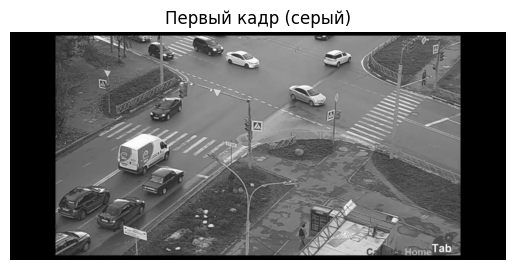

In [1]:
import cv2
import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path

VIDEO_PATH = "video.mov"
MAX_FRAMES = 150   # по заданию возьмем 150 кадров для траектории

cap = cv2.VideoCapture(VIDEO_PATH)

frames_gray = []
frame_count = 0
while frame_count < MAX_FRAMES:
    ret, frame = cap.read()
    if not ret:
        break
    gray = cv2.cvtColor(frame, cv2.COLOR_BGR2GRAY)
    frames_gray.append(gray)
    frame_count += 1
cap.release()

frames_gray = np.array(frames_gray)
print(f"Загружено кадров: {len(frames_gray)}, размер кадра: {frames_gray[0].shape}")
plt.imshow(np.rot90(frames_gray[0]), cmap="gray")
plt.title("Первый кадр (серый)")
plt.axis("off")
plt.show()

## 2. Разреженный оптический поток: Lucas–Kanade (LK)

**Идея LK:** в небольшом окне вокруг точки движение считается постоянным; по градиентам яркости в окне решается система и получается вектор смещения (u, v). Поэтому LK даёт поток только в **выбранных точках** (разреженный).

**Шаги:**
1. **Ключевые точки** — углы и участки с хорошей текстурой. В OpenCV: `cv2.goodFeaturesToTrack` (критерий углов Ши-Томаси).
2. **Отслеживание** — `cv2.calcOpticalFlowPyrLK(prev, next, prev_pts, ...)` по парам кадров; получаем новые координаты точек.
3. **Траектории** — накапливаем позиции каждой точки по кадрам и отбрасываем точки, которые вышли за кадр или потеряли трекинг (по `status`).

In [3]:
# Параметры LK
NUM_POINTS = 250      # число ключевых точек
LK_PARAMS = dict(
    winSize=(21, 21),
    maxLevel=3,
    criteria=(cv2.TERM_CRITERIA_EPS | cv2.TERM_CRITERIA_COUNT, 30, 0.01)
)

# Ключевые точки на первом кадре (goodFeaturesToTrack — углы Ши-Томаси)
points_0 = cv2.goodFeaturesToTrack(
    frames_gray[0],
    maxCorners=NUM_POINTS,
    qualityLevel=0.01,
    minDistance=15,
    blockSize=7
)
if points_0 is None:
    points_0 = np.array([]).reshape(0, 2)
else:
    points_0 = points_0.reshape(-1, 2)

In [4]:
# Отслеживание траекторий по кадрам
n_frames = len(frames_gray)
h, w = frames_gray[0].shape
# Индексы «живых» точек; когда точка теряется — помечаем и больше не трекаем
active = np.ones(len(points_0), dtype=bool)
# Список траекторий: каждая — массив формы (n_frames, 2), невалидные кадры = np.nan
# trajectories[i] — список (x, y) по кадрам для i-й точки
trajectories = [np.full((n_frames, 2), np.nan) for _ in range(len(points_0))] 
for i in range(len(points_0)):
    trajectories[i][0] = points_0[i]

prev_pts = points_0.astype(np.float32)

# Цикл отслеживания точек
for f in range(1, n_frames):
    next_pts, status, _ = cv2.calcOpticalFlowPyrLK(
        frames_gray[f - 1], frames_gray[f], prev_pts, None, **LK_PARAMS
    )
    if next_pts is None:
        active[:] = False
        break
    # status.ravel() == 1 — точка успешно отслежена
    ok = (status.ravel() == 1) & active
    # Отбрасываем точки, вышедшие за границы кадра
    in_bounds = (
        (next_pts[:, 0] >= 0) & (next_pts[:, 0] < w) &
        (next_pts[:, 1] >= 0) & (next_pts[:, 1] < h)
    )
    active &= ok & in_bounds
    # Сохрарнеие траектории активных точек
    for i in range(len(points_0)):
        if active[i]:
            trajectories[i][f] = next_pts[i]
    prev_pts = np.where(active[:, np.newaxis], next_pts, prev_pts)

# Статистика: сколько точек «дожило» до конца
valid_trajectories = [t for t in trajectories if np.any(np.isfinite(t))]
n_valid = sum(1 for t in trajectories if np.sum(np.isfinite(t[:, 0])) >= min(50, n_frames))
print(f"Траекторий с хотя бы 50 кадрами: {n_valid} из {len(points_0)} ключевых точек")

Траекторий с хотя бы 50 кадрами: 247 из 250 ключевых точек


### 3. Визуализация траекторий LK в координатной системе кадра

Рисуем траектории поверх кадра: каждая линия — путь одной точки во времени. Цвет можно задать по времени или по индексу точки.

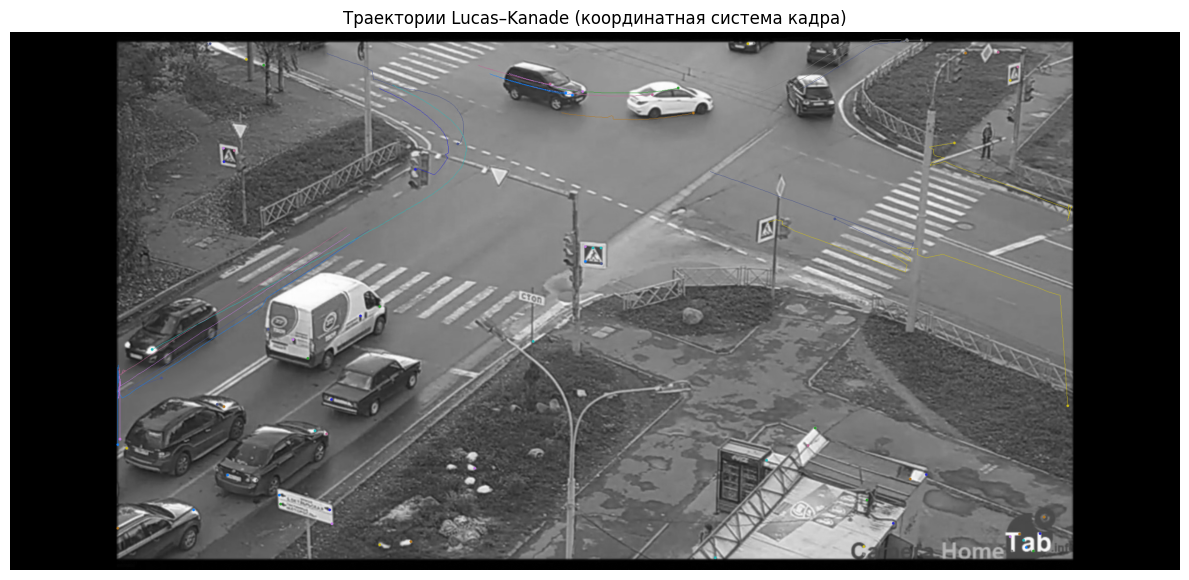

In [5]:
def draw_lk_trajectories(frames_gray, trajectories, frame_index=-1, max_trails=80):
    """Визуализация траекторий LK на выбранном кадре (по умолчанию последний)."""
    idx = frame_index if frame_index >= 0 else len(frames_gray) + frame_index
    img = cv2.cvtColor(frames_gray[idx], cv2.COLOR_GRAY2BGR)
    n_frames = len(frames_gray)
    colors = plt.cm.tab10(np.linspace(0, 1, 10))
    drawn = 0
    for i, traj in enumerate(trajectories):
        if drawn >= max_trails:
            break
        valid = np.isfinite(traj[:, 0])
        if np.sum(valid) < 10:
            continue
        pts = traj[valid].astype(np.int32)
        color = (np.array(colors[i % 10][:3]) * 255).astype(np.uint8).tolist()
        cv2.polylines(img, [pts], isClosed=False, color=color, thickness=1)
        # Текущая позиция точки
        cv2.circle(img, tuple(pts[-1]), 3, color, -1)
        drawn += 1
    return img

# Визуализация на последнем кадре
img_traj = draw_lk_trajectories(frames_gray, trajectories, frame_index=-1)
plt.figure(figsize=(12, 7))
plt.imshow(cv2.cvtColor(np.rot90(img_traj), cv2.COLOR_BGR2RGB))
plt.title("Траектории Lucas–Kanade (координатная система кадра)")
plt.axis("off")
plt.tight_layout()
plt.show()

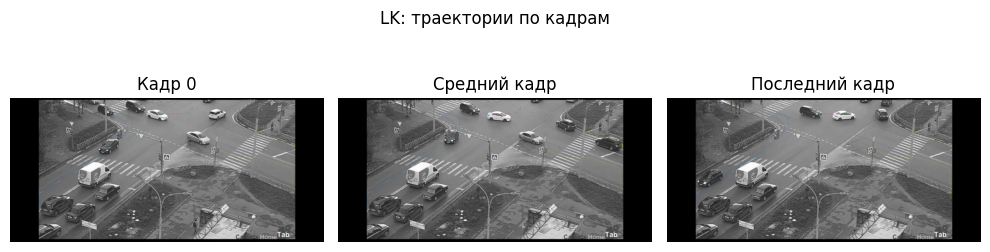

In [6]:
# Визуализация траектории по кадрам для наглядности
fig, axes = plt.subplots(1, 3, figsize=(10, 3))
for ax, fi, title in zip(axes, [0, len(frames_gray)//2, -1], ["Кадр 0", "Средний кадр", "Последний кадр"]):
    im = draw_lk_trajectories(frames_gray, trajectories, frame_index=fi, max_trails=60)
    ax.imshow(cv2.cvtColor(np.rot90(im), cv2.COLOR_BGR2RGB))
    ax.set_title(title)
    ax.axis("off")
plt.suptitle("LK: траектории по кадрам")
plt.tight_layout()
plt.show()

## 4. Плотный оптический поток: Farnebäck

**Идея Farnebäck:** в каждой точке кадра аппроксимируется локальная модель движения (квадратичная по координатам); решая по соседним пикселям, получаем вектор (u, v) **в каждом пикселе** — плотное поле.

**Шаги:**
1. **Поле движения** — `cv2.calcOpticalFlowFarneback(prev, next, ...)` → массив формы (H, W, 2): flow[:,:,0]=u, flow[:,:,1]=v.
2. **Модуль потока** — magnitude = √(u² + v²); большая величина — сильное движение.
3. **Бинарная маска движения** — порог по модулю. Считаем движением, если __magnitude__ > __treshold__

In [7]:
FARNEBACK_PARAMS = dict(
    pyr_scale=0.5, # коэффициент уменьшения на каждом уровне пирамиды
    levels=5,
    winsize=15,   # влияет на устойчивость: большое окно устойчивее, но менее чувствительно
    iterations=5,
    poly_n=5,     # степень сглаживания
    poly_sigma=1.2, # размер полигона аппроксимации
    flags=0
)

def calc_flow_magnitude(prev, next_):
    flow = cv2.calcOpticalFlowFarneback(prev, next_, None, **FARNEBACK_PARAMS)
    mag = np.sqrt(flow[:, :, 0]**2 + flow[:, :, 1]**2)
    return flow, mag

# Для отчёта: поток между кадром 0 и 1, и между двумя кадрами в середине
flow_01, mag_01 = calc_flow_magnitude(frames_gray[0], frames_gray[1])
mid = len(frames_gray) // 2
flow_mid, mag_mid = calc_flow_magnitude(frames_gray[mid - 1], frames_gray[mid])
print("Поле потока (flow) имеет форму:", flow_01.shape, "→ u и v по каналу")

Поле потока (flow) имеет форму: (2622, 1206, 2) → u и v по каналу


### 3.1 Визуализация поля движения (Farnebäck)

Стандартный способ: **HSV-карта**: оттенок = направление потока, яркость/насыщенность = модуль. Либо стрелки (векторы) на сетке.

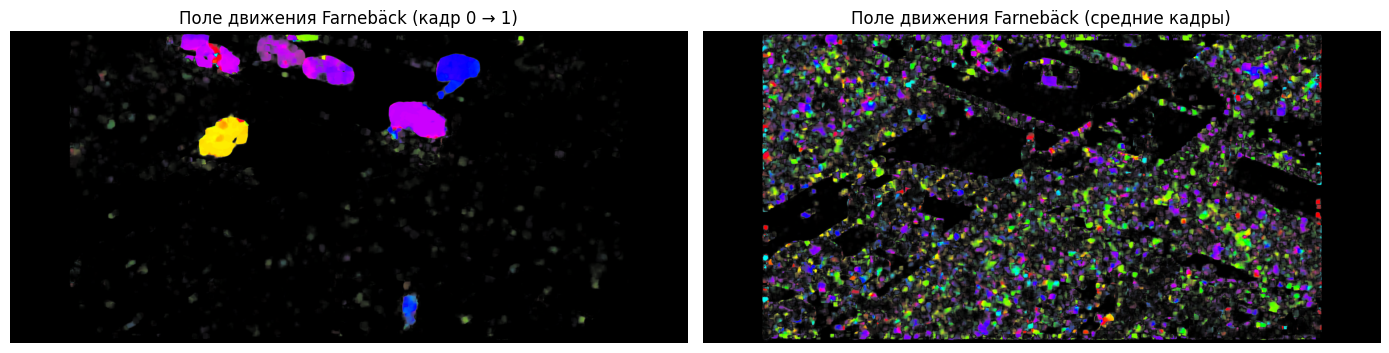

In [8]:
def flow_to_hsv(flow, max_mag=None):
    """Koдиpyeт направление потока в цвет, a модуль — в яркость/насыщенность."""
    fx, fy = flow[:, :, 0], flow[:, :, 1]
    mag = np.sqrt(fx**2 + fy**2)
    if max_mag is None:
        max_mag = np.percentile(mag, 97)  # обрезка выбросов
    mag = np.clip(mag, 0, max_mag)
    ang = np.arctan2(fy, fx)
    H = (ang + np.pi) / (2 * np.pi) * 180  # 0..180 для OpenCV
    S = np.clip(mag / (max_mag + 1e-6) * 255, 0, 255).astype(np.uint8)
    V = np.clip(mag / (max_mag + 1e-6) * 255, 0, 255).astype(np.uint8)
    H = np.clip(H, 0, 180).astype(np.uint8)
    hsv = cv2.merge([H, S, V])
    bgr = cv2.cvtColor(hsv, cv2.COLOR_HSV2BGR)
    return bgr

# Поле движения: кадры 0→1 и середина
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
axes[0].imshow(cv2.cvtColor(np.rot90(flow_to_hsv(flow_01)), cv2.COLOR_BGR2RGB))
axes[0].set_title("Поле движения Farnebäck (кадр 0 → 1)")
axes[0].axis("off")
axes[1].imshow(cv2.cvtColor(np.rot90(flow_to_hsv(flow_mid)), cv2.COLOR_BGR2RGB))
axes[1].set_title("Поле движения Farnebäck (средние кадры)")
axes[1].axis("off")
plt.tight_layout()
plt.show()

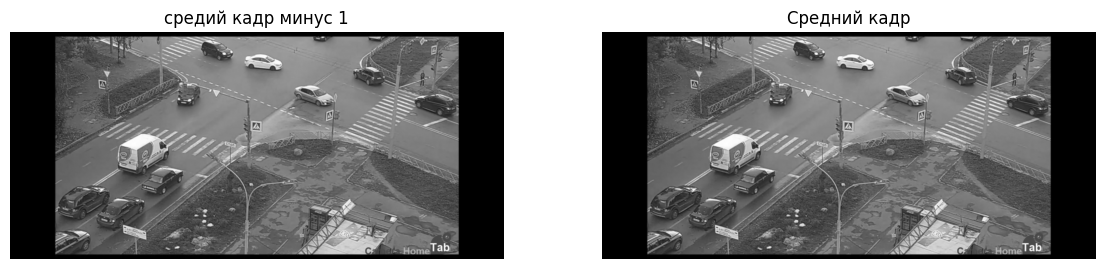

In [10]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))
ax1.imshow(np.rot90(frames_gray[mid-1]), cmap="gray")
ax1.set_title("средий кадр минус 1")
ax1.axis("off") 
ax2.imshow(np.rot90(frames_gray[mid]), cmap="gray")
ax2.set_title("Средний кадр")
ax2.axis("off")
plt.show()

#### 4.1 Бинарные маски движения по модулю потока

Выделяем движущиеся области: где модуль потока выше порога — «движение», иначе — фон. Порог подбирается по гистограмме или вручную.

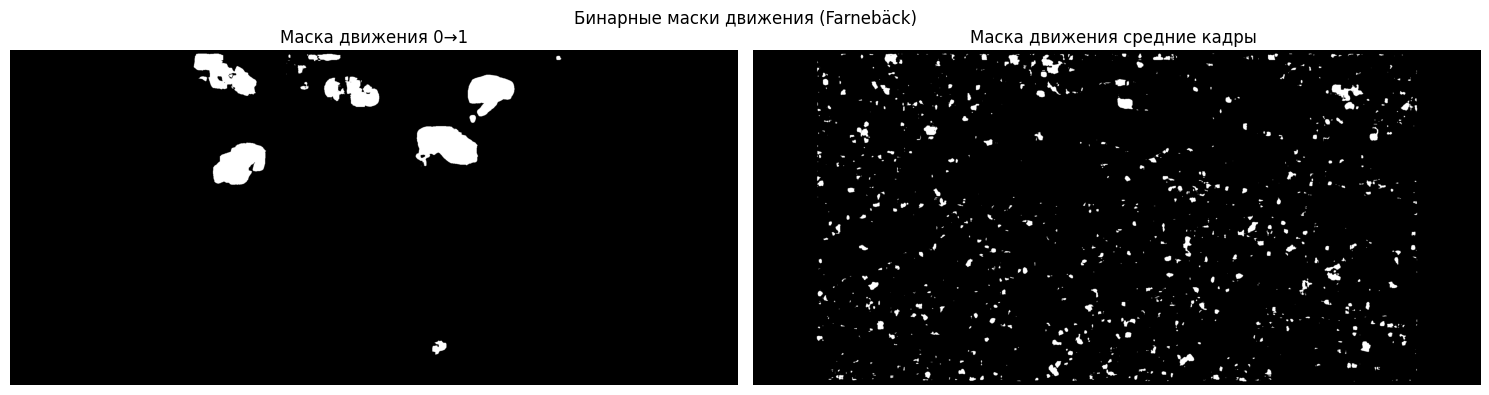

In [11]:
def motion_mask(mag, threshold_percentile=97):
    """Бинарная маска: 1 где модуль потока выше порога (по перцентилю)."""
    threshold = np.percentile(mag, threshold_percentile)
    return (mag >= threshold).astype(np.uint8) * 255

MASK_PERCENTILE = 97  # верхние 3% по величине потока — движение
mask_01 = motion_mask(mag_01, MASK_PERCENTILE)
mask_mid = motion_mask(mag_mid, MASK_PERCENTILE)

fig, axes = plt.subplots(1, 2, figsize=(15, 4))
axes[0].imshow(np.rot90(mask_01), cmap="gray")
axes[0].set_title("Маска движения 0→1")
axes[0].axis("off")
axes[1].imshow(np.rot90(mask_mid), cmap="gray")
axes[1].set_title("Маска движения средние кадры ")
axes[1].axis("off")

plt.suptitle("Бинарные маски движения (Farnebäck)")
plt.tight_layout()
plt.show()

## 5. Сравнение чувствительности к текстуре, motion blur, теням и шуму

**Кратко по факторам:**

- **Текстура:** LK сильно зависит от углов/градиентов — на гладких областях точки не находятся или теряются. Farnebäck даёт поток везде, но на однородных зонах он ненадёжен (шум).
- **Motion blur:** при смазе градиенты искажаются — LK даёт ошибки или потерю точек. Farnebäck тоже «размазывает» поток.
- **Тени:** смена освещения нарушает предположение постоянства яркости — оба метода могут давать ложное движение по границам теней.
- **Шум:** LK устойчивее в окне (усреднение); Farnebäck чувствителен к шуму в каждом пикселе — маска движения может фрагментироваться.

Ниже — количественнaя метрикa и качественные наблюдения.

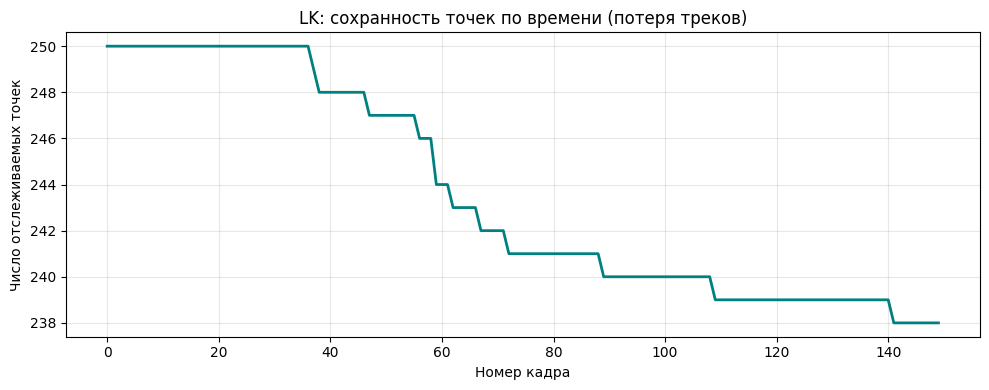

Начало: 250 точек, конец: 238 точек. Потеряно: 12


In [12]:
# Количественный разбор: LK — сколько точек потеряно по кадрам
survival = []
for f in range(n_frames):
    n_alive = sum(1 for t in trajectories if np.isfinite(t[f, 0]))
    survival.append(n_alive)

plt.figure(figsize=(10, 4))
plt.plot(survival, color="teal", linewidth=2)
plt.xlabel("Номер кадра")
plt.ylabel("Число отслеживаемых точек")
plt.title("LK: сохранность точек по времени (потеря треков)")
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()
print(f"Начало: {survival[0]} точек, конец: {survival[-1]} точек. Потеряно: {survival[0] - survival[-1]}")

In [13]:
# Farnebäck: «шумность» маски — число связных компонент (фрагментация)
def count_components(mask):
    n_labels, labels, stats, _ = cv2.connectedComponentsWithStats(mask, connectivity=8)
    return n_labels - 1  # без фона

n_comp_raw = count_components(mask_01)
print(f"{n_comp_raw} связных компонент (фрагментация/шум)")

# Доля «движения» в кадре
motion_ratio = np.mean(mask_01 > 0)
print(f"Доля пикселей c движением: {motion_ratio*100:.1f}%")

27 связных компонент (фрагментация/шум)
Доля пикселей c движением: 3.0%


## 6. Качественный и количественный разбор ошибок

**Где LK теряет точки:**
- Гладкие области без текстуры (небо, стены).
- Сильный motion blur — градиенты «размазаны», решение LK неустойчиво.


**Где плотный поток (Farnebäck) выдаёт шум:**
- Однородные области — поток не определён однозначно, появляются случайные векторы.
- Шум в изображении усиливается в маске движения.
- Малые движения (дрожание камеры, шум) дают ненулевой модуль → ложные срабатывания в маске.

**Где маска движения фрагментируется:**
- Порог по модулю отсекает слабое движение и оставляет только сильное — объект может разбиться на пятна(пример:средний кадр в видеопотоке).


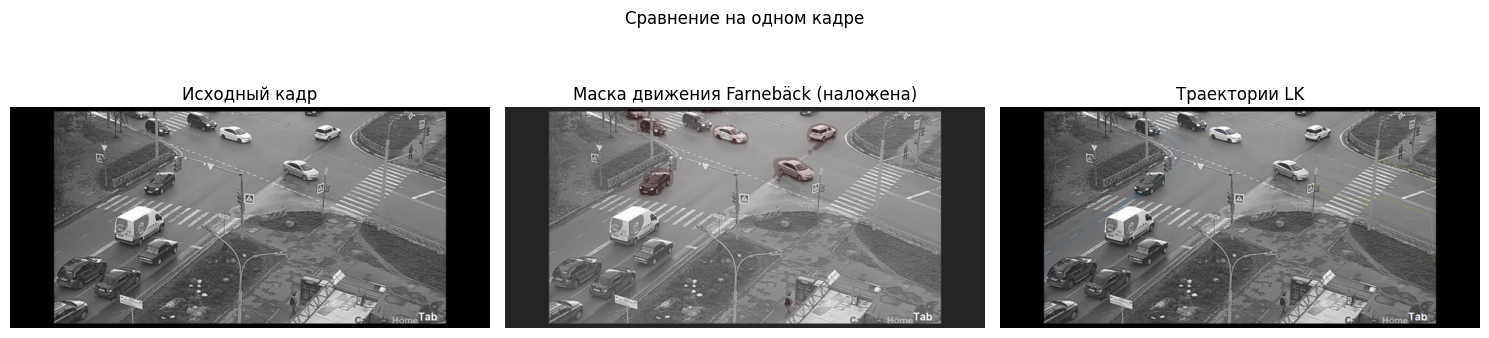

In [14]:
fig, axes = plt.subplots(1, 3, figsize=(15, 4))
frame_idx = 1 
axes[0].imshow(np.rot90(frames_gray[frame_idx]), cmap="gray")
axes[0].set_title("Исходный кадр")
axes[0].axis("off")

# Маска для этого перехода (frame_idx-1 -> frame_idx)
flow_f, mag_f = calc_flow_magnitude(frames_gray[frame_idx-1], frames_gray[frame_idx])
mask_f = motion_mask(mag_f, MASK_PERCENTILE)
axes[1].imshow(np.rot90(frames_gray[frame_idx]), cmap="gray")
axes[1].imshow(np.rot90(mask_f), alpha=0.15, cmap="Reds")
axes[1].set_title("Маска движения Farnebäck (наложена)")
axes[1].axis("off")

im_traj = draw_lk_trajectories(frames_gray, trajectories, frame_index=frame_idx, max_trails=50)
axes[2].imshow(cv2.cvtColor(np.rot90(im_traj), cv2.COLOR_BGR2RGB))
axes[2].set_title("Траектории LK")
axes[2].axis("off")
plt.suptitle("Сравнение на одном кадре")
plt.tight_layout()
plt.show()

## 7. Краткое исследование: когда выбирать LK, когда Farnebäck

| Критерий | Lucas–Kanade | Farnebäck |
|----------|--------------|-----------|
| **Скорость** | Быстрее (мало точек) | Медленнее (поток в каждом пикселе) |
| **Текстурные области** | Надёжные траектории в углах/градиентах | Поле везде, но на гладких зонах — шум |
| **Задача** | Трекинг конкретных точек (маркеры, ключевые объекты) | Сегментация движения, фон/передний план, карта движения |
| **Память** | Мало данных (только координаты точек) | Полное поле (H×W×2 float) |

**Вывод:**  
- **LK** выбирают, когда нужны **траектории ограниченного числа точек** (трекинг людей/машин по ключевым точкам, стабилизация по точкам). Важно наличие текстуры и умеренный blur.  
- **Farnebäck** выбирают, когда нужна **плотная карта движения** или **бинарная маска «где движется»** (детекция движения, сегментация по движению, анализ сцен). Допустим шум в однородных зонах, если важна полнота покрытия.  
